In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np

csv_path = "/Users/borjacervera/Documents/Ironhack/Labs/Unit5_W13/amz_uk_price_prediction_dataset.csv"
df = pd.read_csv(csv_path)


In [6]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [7]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [8]:
category_column = "category"
category_counts = df[category_column].value_counts()
print(category_counts)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64


In [10]:
print(df["isBestSeller"].unique())

[False  True]


In [13]:
crosstab = pd.crosstab(df[category_column], df[bestseller_column])

print(crosstab.columns)

if 1 in crosstab.columns and 0 in crosstab.columns:
    crosstab["BestSeller_Proportion"] = crosstab[1] / (crosstab[0] + crosstab[1])
else:
    crosstab["BestSeller_Proportion"] = crosstab.iloc[:, 1] / (crosstab.iloc[:, 0] + crosstab.iloc[:, 1])

crosstab = crosstab.sort_values(by="BestSeller_Proportion", ascending=False)
print(crosstab)

Index([False, True], dtype='bool', name='isBestSeller')
isBestSeller                      False  True  BestSeller_Proportion
category                                                            
Grocery                            9008   556               0.058135
Smart Home Security & Lighting       98     6               0.057692
Health & Personal Care             9017   552               0.057686
Mobile Phone Accessories            248    11               0.042471
Power & Hand Tools                 8353   306               0.035339
...                                 ...   ...                    ...
CD, Disc & Tape Players            8798     0               0.000000
General Music-Making Accessories    259     0               0.000000
Snowboard Boots                    1449     0               0.000000
Boxes & Organisers                  911     0               0.000000
eBook Readers & Accessories         246     0               0.000000

[296 rows x 3 columns]


In [15]:
# Prueba de independencia de Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df[category_column], df[bestseller_column]))

print(f"Chi-square: {chi2}")
print(f"p-Value: {p}")
print(f"Freedom: {dof}")

# Interpretación del p-valor
if p < 0.05:
    print("Exist correlation")
else:
    print("There is not relation.")

Chi-square: 36540.20270061387
p-Value: 0.0
Freedom: 295
Exist correlation


In [16]:
n = df.shape[0]  
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))

print(f"Cramers V: {cramers_v}")

Cramers V: 0.08646709890892415


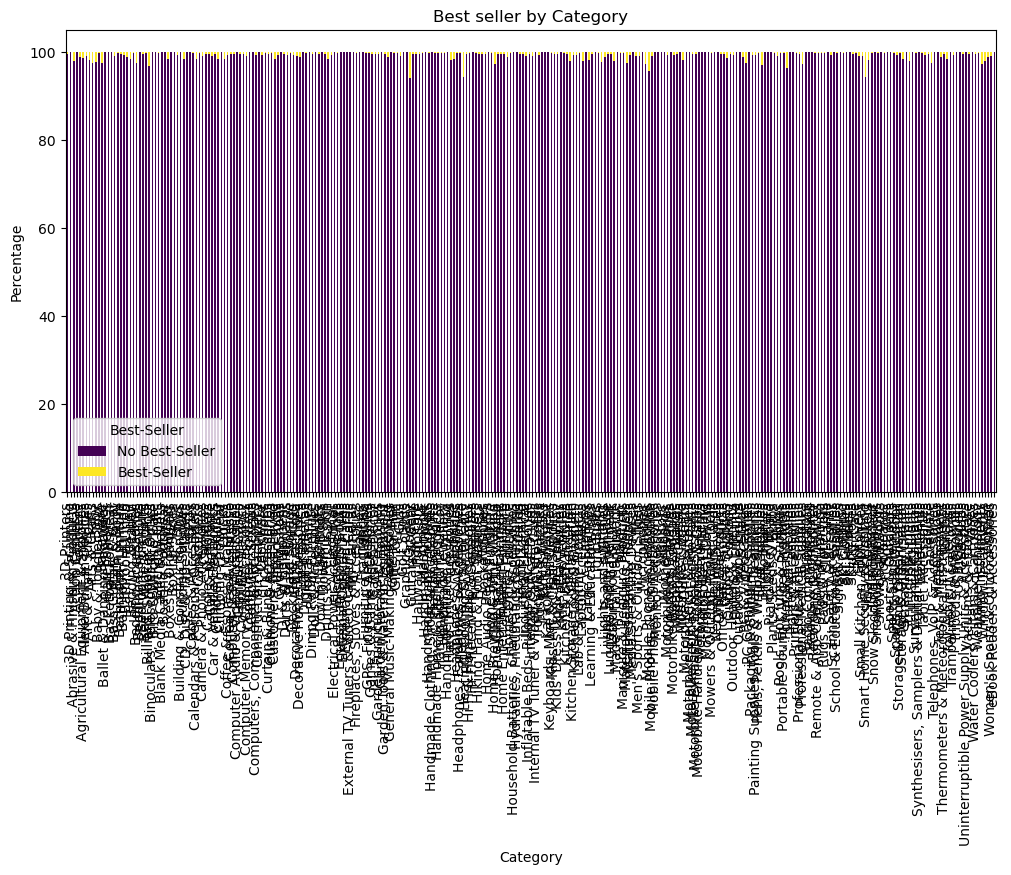

In [17]:
crosstab_percent = pd.crosstab(df[category_column], df[bestseller_column], normalize='index') * 100

crosstab_percent.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.title("Best seller by Category")
plt.legend(["No Best-Seller", "Best-Seller"], title="Best-Seller")
plt.xticks(rotation=90)
plt.show()

In [18]:
price_column = "price"

Q1 = df[price_column].quantile(0.25)
Q3 = df[price_column].quantile(0.75)
IQR = Q3 - Q1

df_filtered = df[(df[price_column] >= (Q1 - 1.5 * IQR)) & (df[price_column] <= (Q3 + 1.5 * IQR))]

print(f"Original dataset: {df.shape[0]}")
print(f"Dataset without outliers: {df_filtered.shape[0]}")

Original dataset: 2443651
Dataset without outliers: 2115963


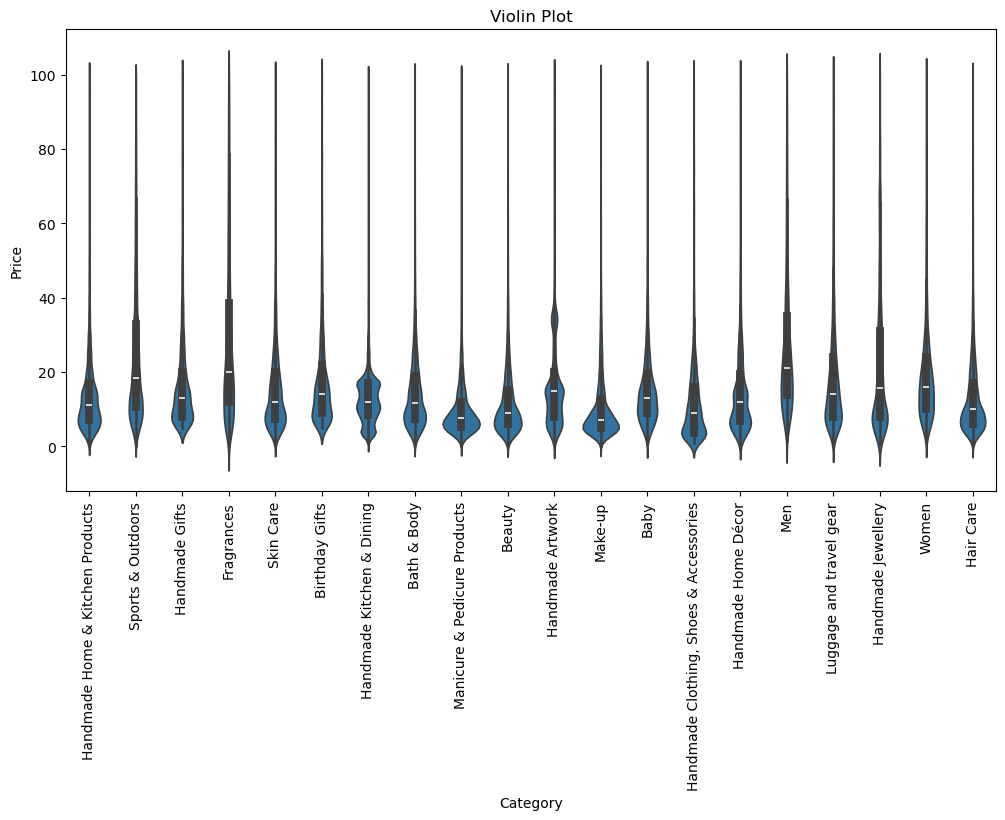

In [20]:
category_column = "category"

top_20_categories = df_filtered[category_column].value_counts().index[:20]
df_top_categories = df_filtered[df_filtered[category_column].isin(top_20_categories)]

plt.figure(figsize=(12, 6))
sns.violinplot(x=df_top_categories[category_column], y=df_top_categories[price_column])
plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("Price")
plt.title("Violin Plot")
plt.show()

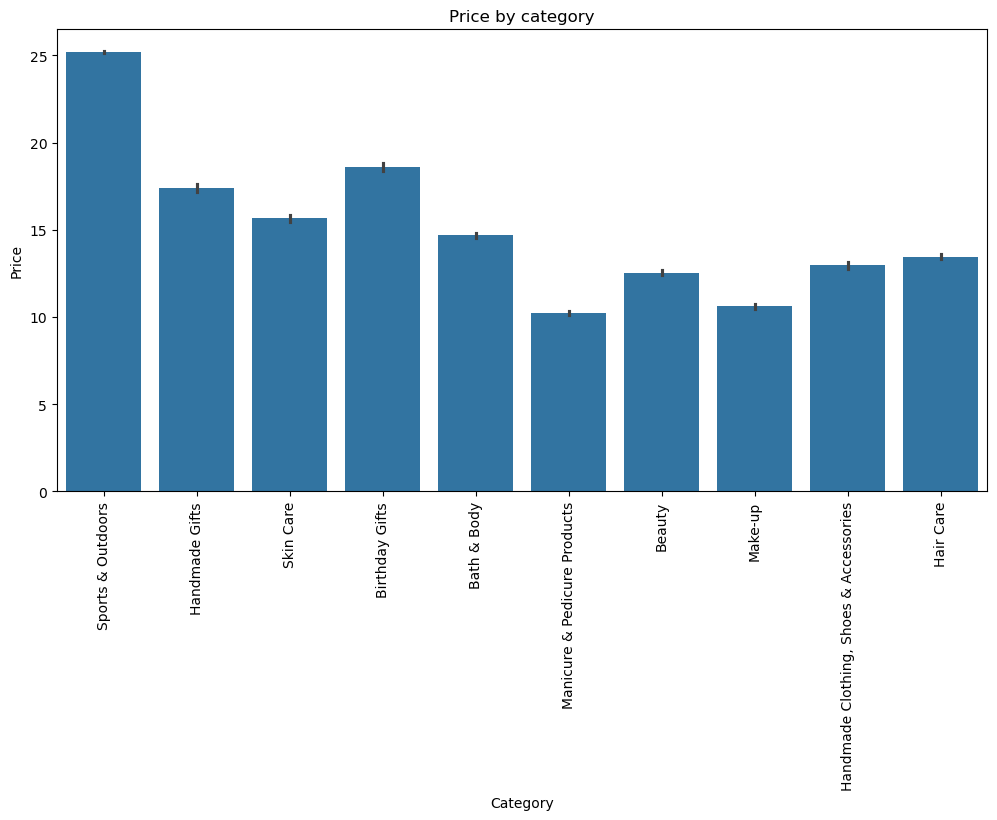

In [21]:
avg_price_by_category = df_filtered.groupby(category_column)[price_column].mean().sort_values(ascending=False)

top_10_categories = df_filtered[category_column].value_counts().index[:10]
df_top_10 = df_filtered[df_filtered[category_column].isin(top_10_categories)]

plt.figure(figsize=(12, 6))
sns.barplot(x=df_top_10[category_column], y=df_top_10[price_column], estimator=lambda x: x.mean())
plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("Price")
plt.title("Price by category")
plt.show()

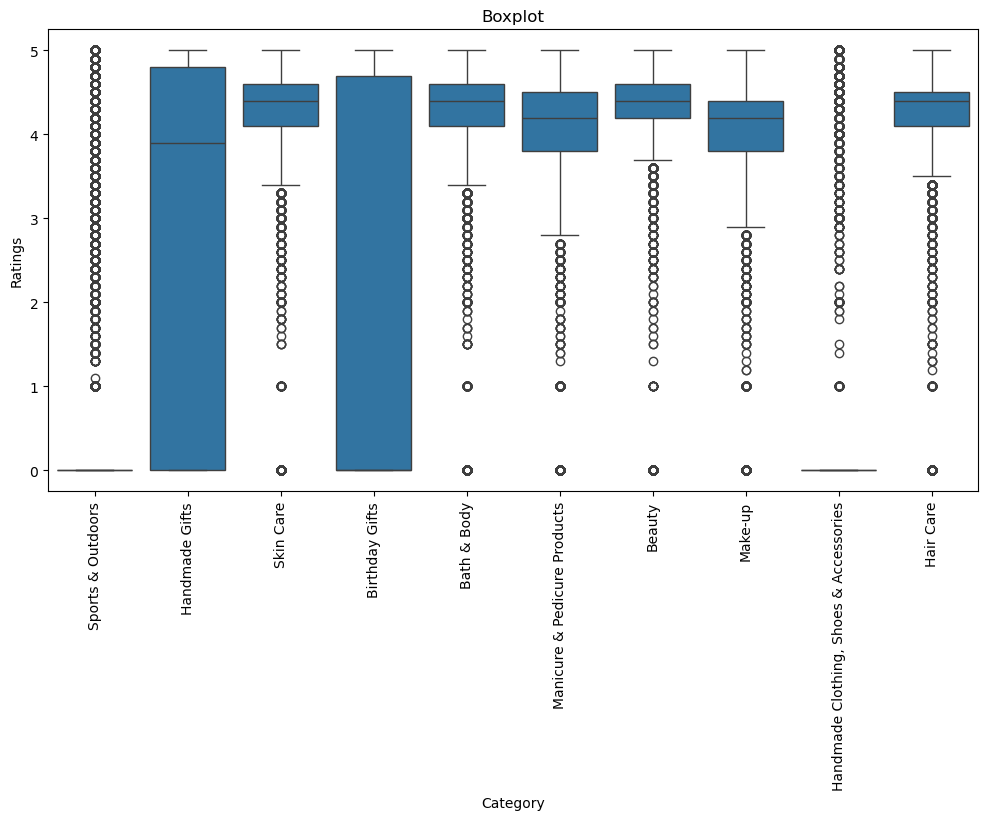

In [23]:
rating_column = "stars"

df_top_10_ratings = df_filtered[df_filtered[category_column].isin(top_10_categories)]

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_top_10_ratings[category_column], y=df_top_10_ratings[rating_column])
plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("Ratings")
plt.title("Boxplot")
plt.show()

In [25]:
price_column = "price"
stars_column = "stars"
correlation = df[price_column].corr(df[stars_column])

print(f"Correlation: {correlation}")

Correlation: -0.12490673262148386


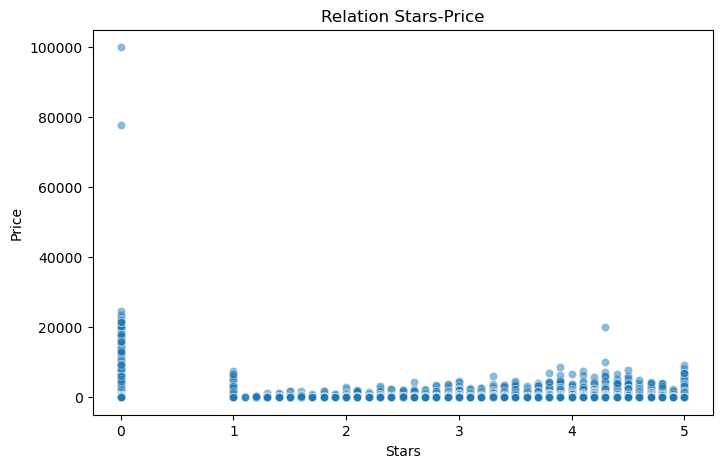

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[stars_column], y=df[price_column], alpha=0.5)
plt.xlabel("Stars")
plt.ylabel("Price")
plt.title("Relation Stars-Price")
plt.show()

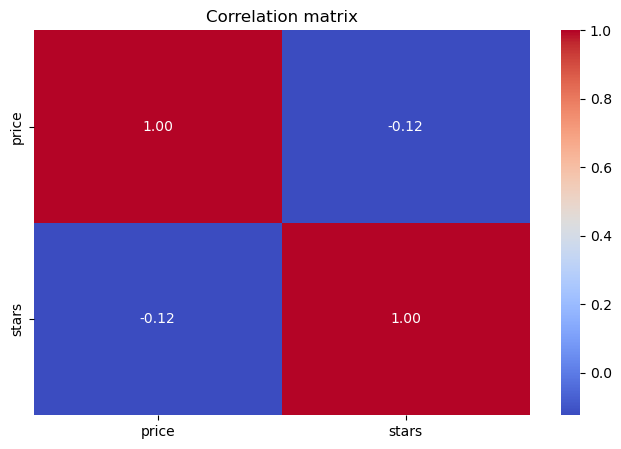

In [27]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[[price_column, stars_column]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

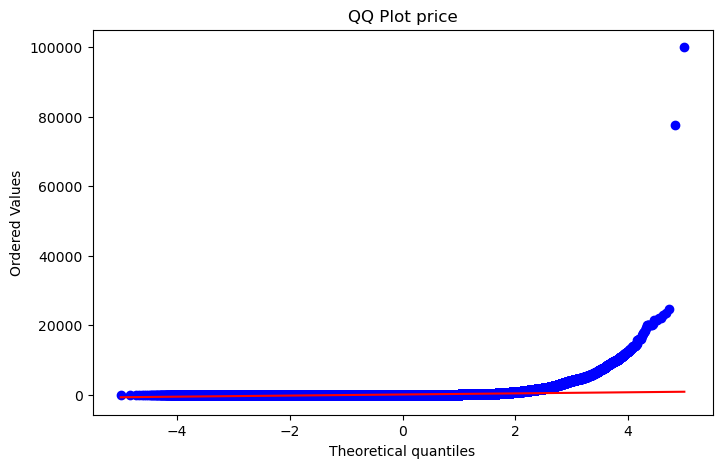

In [28]:
import scipy.stats as stats

plt.figure(figsize=(8, 5))
stats.probplot(df[price_column], dist="norm", plot=plt)
plt.title("QQ Plot price")
plt.show()